In [1]:
import wandas as wd
import numpy as np
import matplotlib.pyplot as plt

## Scenario 1: 基本的な信号生成と可視化

🗣️ User Prompt

wandasを使って、440Hzのサイン波を1秒間生成し、その波形を表示してください。振幅は1Paでサンプリングレートは44.1kHzでお願いします。

✅ Expected Code

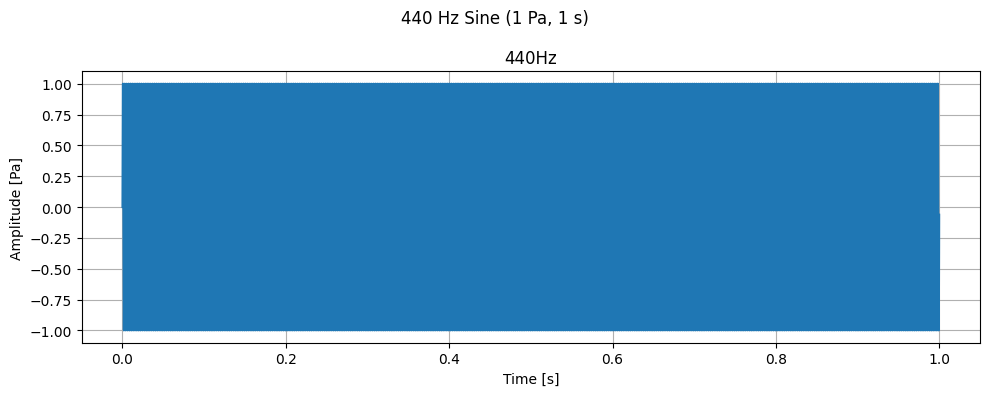

In [2]:
# 440 Hz サイン波を生成して表示 (1 s, 1 Pa, 44.1 kHz)
import numpy as np
import wandas as wd

fs = 44100
duration = 1.0
f = 440.0
amplitude = 1.0  # Pa

n = int(fs * duration)
t = np.arange(n) / fs
sig = amplitude * np.sin(2 * np.pi * f * t)

# ChannelFrame を作成して wandas の plot() で表示
frame = wd.from_numpy(data=sig, sampling_rate=fs, ch_labels=['440Hz'], ch_units='Pa')

frame.plot(title='440 Hz Sine (1 Pa, 1 s)')

## Scenario 2: ノイズ除去（フィルタリング）とFFT

複数の周波数成分を持つ信号を作り、フィルタで特定成分を除去するフローです。

🗣️ User Prompt

テスト用に1kHzの信号と50Hzのノイズが混ざったデータを作ってください（長さ2秒、レート10kHz）。
その後、ハイパスフィルタで50Hzのノイズを除去し、FFT解析を行ってスペクトルを表示してください。
フィルタ適用前後で効果がわかるように重ね書きをお願い。
#sym:# Wandas Signal Analysis Skill に従いwandasを使ってください。

✅ Expected Code



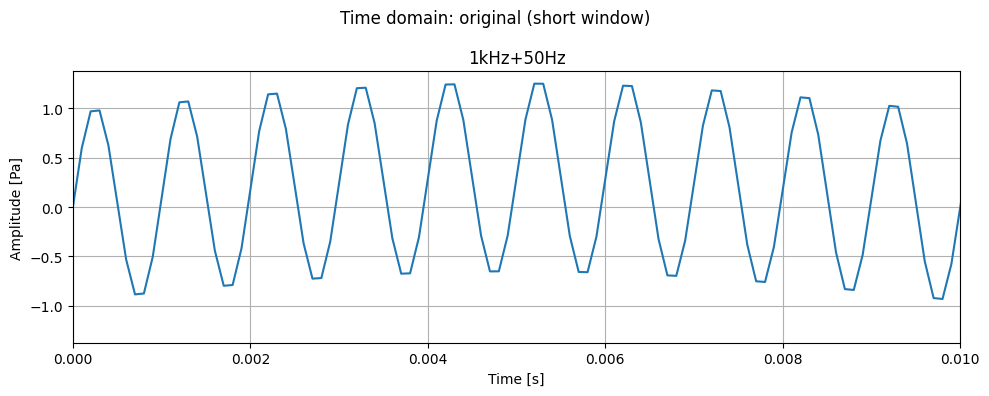

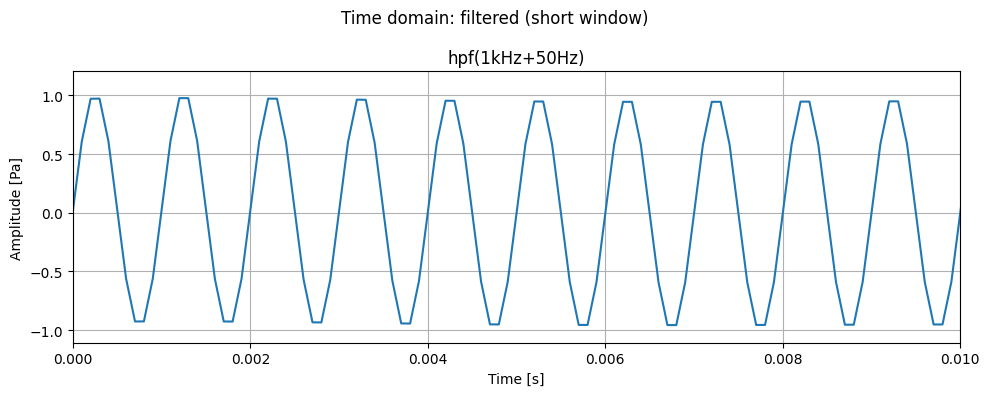

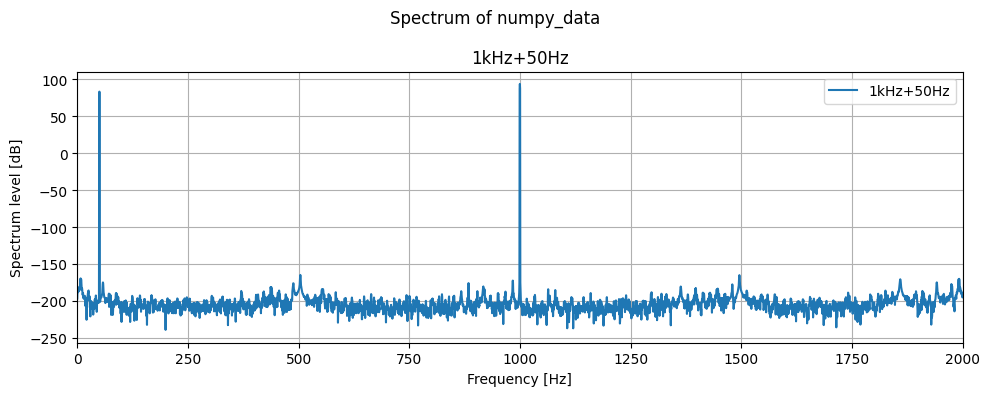

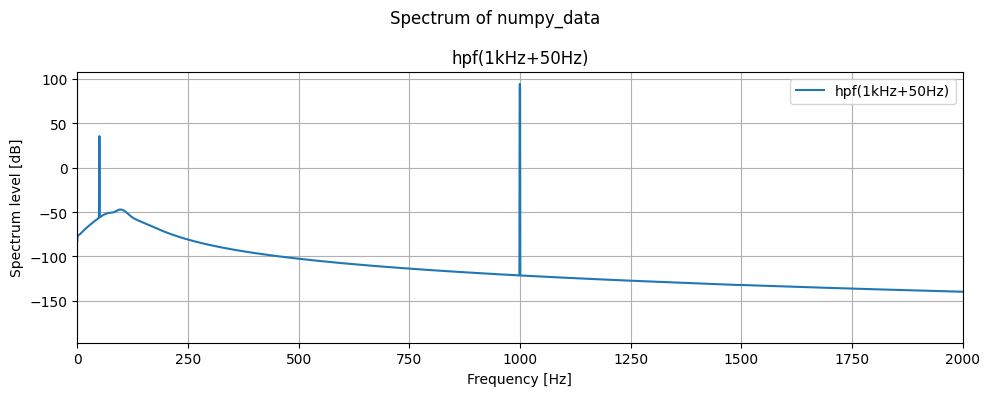

In [11]:
# Generate 1 kHz signal with 50 Hz noise, apply high-pass filter, and show FFT overlay using wandas
import numpy as np
import wandas as wd

fs = 10000  # sampling rate
duration = 2.0
t = np.arange(int(fs * duration)) / fs

# Signal: 1 kHz tone + 50 Hz noise (noise smaller amplitude)
sig = 1.0 * np.sin(2 * np.pi * 1000.0 * t) + 0.3 * np.sin(2 * np.pi * 50.0 * t)

# Create wandas ChannelFrame (time-domain) with units in Pa
frame = wd.from_numpy(data=sig, sampling_rate=fs, ch_labels=['1kHz+50Hz'], ch_units='Pa')

# Apply high-pass filter at 100 Hz using wandas (method chaining)
filtered_frame = frame.high_pass_filter(cutoff=100.0)

# Compute FFT (spectral frames) before and after using wandas
spec_before = frame.fft()
spec_after = filtered_frame.fft()

# Plot time-domain using wandas plotting (short window for clarity)
frame.plot(title='Time domain: original (short window)', xlim=(0, 0.01))
filtered_frame.plot(title='Time domain: filtered (short window)', xlim=(0, 0.01))

# Plot frequency-domain spectra using wandas' plot (x range 0-2 kHz)
spec_before.plot(label='Before (1kHz + 50Hz)', xlim=(0, 2000))
spec_after.plot(label='After (HPF 100 Hz)', xlim=(0, 2000))

# Per Wandas Signal Analysis Skill, visualization is done via .plot() methods above.


## Scenario 3: 時間周波数解析 (STFT)

スペクトログラムの描画パラメータが正しく設定されるか確認します。

🗣️ User Prompt

440Hzと880Hzの音が鳴っている2秒間のデータを作ってください（サンプリングレート20kHz、振幅は0.5 Pa）。
これをSTFT解析して、スペクトログラム（カラーマップ）を表示したいです。

見やすいようにカラーマップは 'jet' にして、FFTサイズは1024に設定してください。
周波数は0~1kHz、時間軸は0~1秒、カラーマップは20~80dBにしてください。

#file:SKILL.md に従いwandasを使ってください。


✅ Expected Code

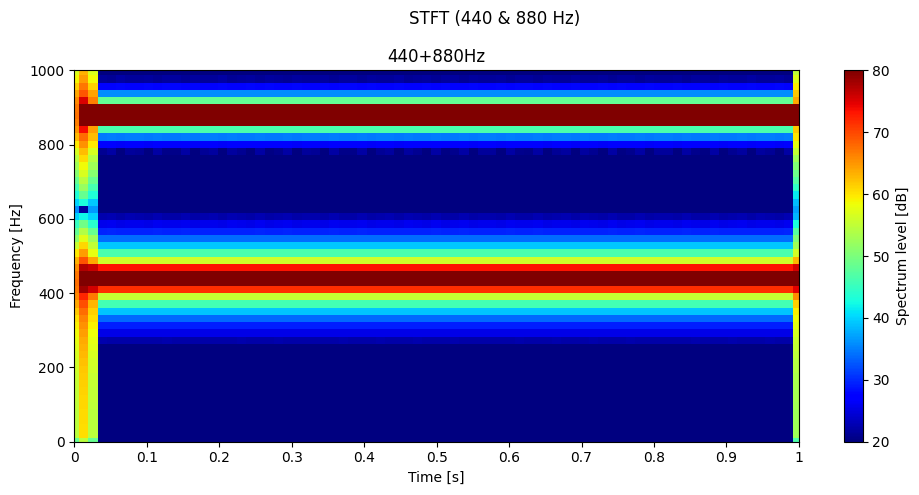

In [1]:
# Generate 2-second signal (440 Hz + 880 Hz), sample rate 20 kHz, amplitude 0.5 Pa
import numpy as np
import wandas as wd

fs = 20000
duration = 2.0
t = np.arange(int(fs * duration)) / fs

# 0.5 Pa amplitude for each tone
sig = 0.5 * np.sin(2 * np.pi * 440.0 * t) + 0.5 * np.sin(2 * np.pi * 880.0 * t)

# Create a ChannelFrame with units in Pa
frame = wd.from_numpy(data=sig, sampling_rate=fs, ch_labels=['440+880Hz'], ch_units='Pa')

# For display, use the first 1 second (time axis 0-1 s)
frame_1s = wd.from_numpy(data=sig[:fs], sampling_rate=fs, ch_labels=['440+880Hz'], ch_units='Pa')

# STFT with FFT size 1024, reasonable hop length for time resolution
(
    frame_1s
    .stft(n_fft=1024, hop_length=256)
    .plot(cmap='jet', vmin=20, vmax=80, xlim=(0, 1.0), ylim=(0, 1000), title='STFT (440 & 880 Hz)')
)
